In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gc
import os
import sys

import warnings
warnings.filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt
from pathlib import Path

In [3]:
ROOT = Path('Z:/multiomics based manuscript/REVISION AFTER JMS/OUP_BA_REVIEWER_COMMENTS/independent_cohort/SHAP')

In [4]:
## change the dataframe_name here for CNV, RNA, and full
dfs = [pd.read_csv(f) for f in ROOT.glob('*_full_*.csv')]

In [5]:
shap_on_df = sum(df.abs() for df in dfs)

In [6]:
shap_on_df_mean = shap_on_df.mean(axis=0)

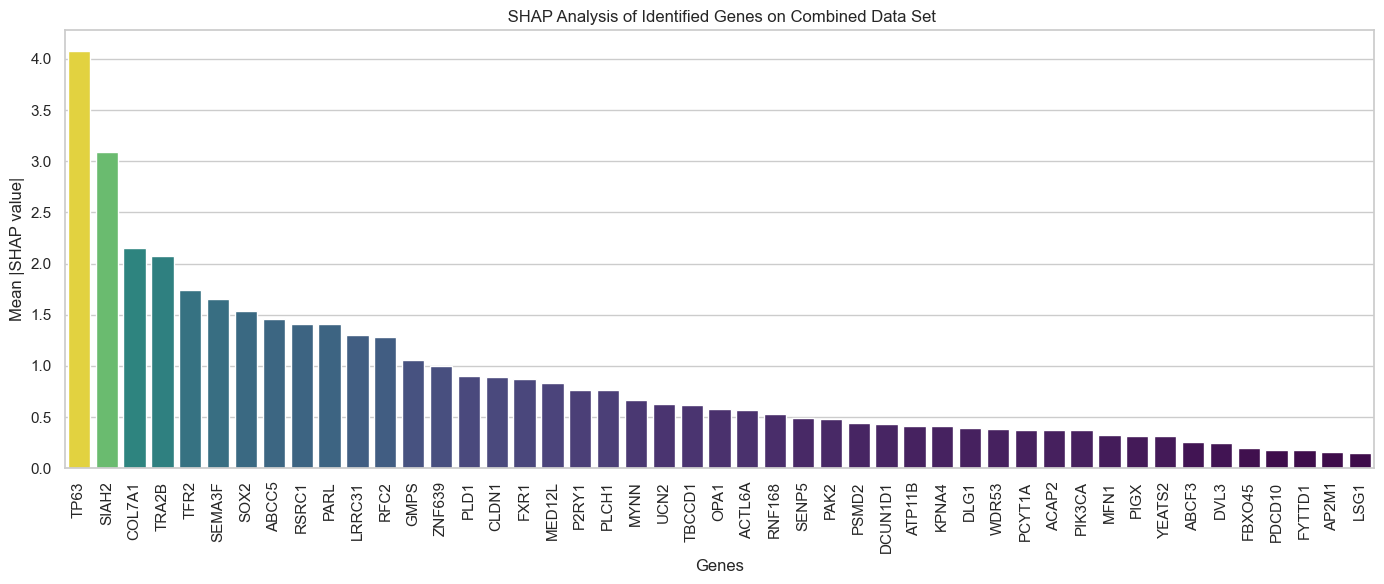

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# Sort column averages (recommended for heatmap effect)
col_means_sorted = shap_on_df_mean.sort_values(ascending=False)

# Create color palette from a colormap
cmap = cm.get_cmap("viridis")
norm = plt.Normalize(col_means_sorted.min(), col_means_sorted.max())
colors = cmap(norm(col_means_sorted.values))

# Convert to seaborn palette
palette = sns.color_palette(colors)

sns.set(style="whitegrid")

plt.figure(figsize=(14, 6))

sns.barplot(
    x=col_means_sorted.index,
    y=col_means_sorted.values,
    palette=palette
)

plt.xlabel("Genes")
plt.ylabel("Mean |SHAP value|")
plt.title(" SHAP Analysis of Identified Genes on Combined Data Set")

plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig(ROOT/"SHAPplot_full.png", dpi=600, bbox_inches='tight')
plt.savefig(ROOT/"SHAPplot_full.pdf", dpi=600, bbox_inches='tight')
plt.show()
